# Importing all the Libraries

In [6]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

# Set all the Constants

In [11]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50

# Import data into tensorflow dataset object

In [16]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [20]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [22]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 256, 256, 3)
[1 1 0 1 0 0 1 0 0 1 1 1 0 2 2 0 0 0 0 0 0 1 1 1 0 2 0 1 0 1 2 1]


dataset.take(1)
→ Takes one batch from the dataset.

If:
BATCH_SIZE = 32

then one batch contains:
- 32 images
- 32 labels

Output:
(32, 256, 256, 3)

Meaning:
- 32  → number of images in batch
- 256 → image height
- 256 → image width
- 3   → RGB color channels (Red, Green, Blue)
  
- Early_blight = 0,
Late_blight = 1,
healthy = 2

Overall:
TensorFlow loaded 32 colored images of size 256×256 pixels.


# Visualize some of the images from our dataset

(32, 256, 256, 3)
[0 2 1 2 1 0 0 1 0 0 0 0 1 1 0 1 0 1 0 1 1 0 2 0 2 0 0 1 0 1 1 0]


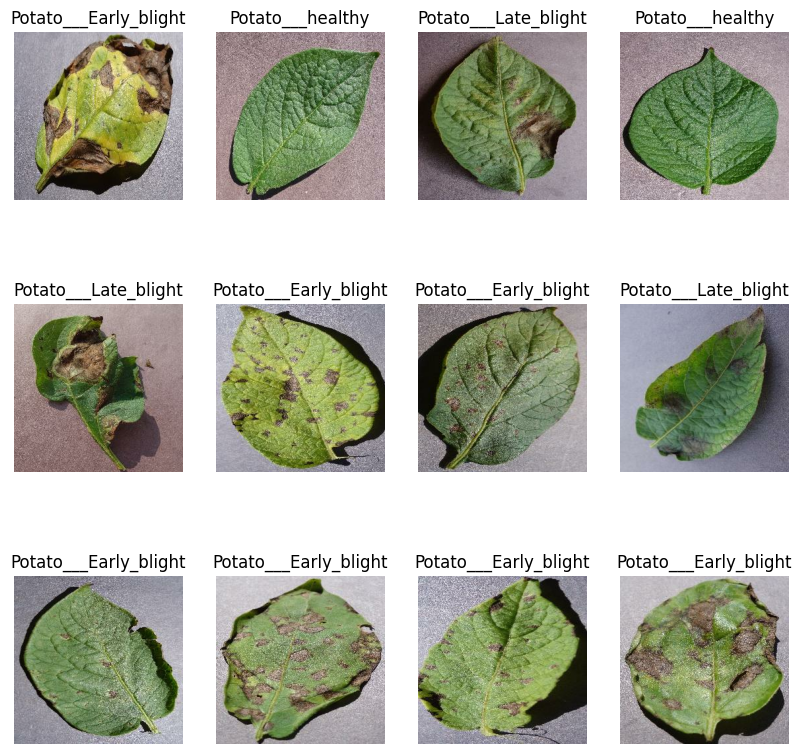

In [30]:
plt.figure(figsize = (10,10))
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(class_names[labels_batch[i]])
        plt.axis('off')

# Function to Split Dataset
Dataset should be bifurcated into 3 subsets, namely:

1. Training: Dataset to be used while training
2. Validation: Dataset to be tested against while training
3. Test: Dataset to be tested against after we trained a model

* 80% ==> training
* 20 ==> test
    * 10% ==> validation
    * 10% ==> test

In [32]:
len(dataset)

68

In [33]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [35]:
train_ds = dataset.take(54)
len(train_ds)

54

In [36]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [39]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [41]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [43]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [51]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)

    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [53]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [54]:
len(train_ds)

54

In [55]:
len(val_ds)

6

In [56]:
len(test_ds)

8

# Cache, Shuffle, and Prefetch the Dataset

In [80]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

# Building the Model

* Creating a Layer for Resizing and Normalization

In [58]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch[0].numpy()/256)

[[[0.71484375 0.70703125 0.76171875]
  [0.71875    0.7109375  0.765625  ]
  [0.76953125 0.76171875 0.81640625]
  ...
  [0.54296875 0.52734375 0.58203125]
  [0.6640625  0.6484375  0.703125  ]
  [0.703125   0.6875     0.7421875 ]]

 [[0.71875    0.7109375  0.765625  ]
  [0.69140625 0.68359375 0.73828125]
  [0.703125   0.6953125  0.75      ]
  ...
  [0.66796875 0.65234375 0.70703125]
  [0.61328125 0.59765625 0.65234375]
  [0.62890625 0.61328125 0.66796875]]

 [[0.70703125 0.69921875 0.75      ]
  [0.6875     0.6796875  0.73046875]
  [0.7109375  0.703125   0.75390625]
  ...
  [0.55859375 0.54296875 0.59765625]
  [0.6171875  0.6015625  0.65625   ]
  [0.765625   0.75       0.8046875 ]]

 ...

 [[0.87109375 0.859375   0.88671875]
  [0.8125     0.80078125 0.828125  ]
  [0.8046875  0.79296875 0.8203125 ]
  ...
  [0.7578125  0.73046875 0.76171875]
  [0.6640625  0.63671875 0.66796875]
  [0.7109375  0.68359375 0.71484375]]

 [[0.8828125  0.87109375 0.8984375 ]
  [0.828125   0.81640625 0.84375   ]


In [65]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Rescaling(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

# Data Augmentation

In [66]:
data_augmentaion = tf.keras.Sequential([
        layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
        layers.experimental.preprocessing.RandomRotation(0.2)
])

# Model Creation

In [73]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [75]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (32, 256, 3)              0         
                                                                 
 conv2d_12 (Conv2D)          (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d_12 (MaxPooli  (32, 127, 127, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_13 (Conv2D)          (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPooli  (32, 62, 62, 64)          0         
 ng2D)                                                           
                                                                 
 conv2d_14 (Conv2D)          (32, 60, 60, 64)         

# Model Compiling

In [78]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['accuracy']
)

In [79]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=50,
)

Epoch 1/50

54/54 [==============================] - 36s 628ms/step - loss: 1.3064 - accuracy: 0.5417 - val_loss: 0.7717 - val_accuracy: 0.6863
Epoch 2/50
54/54 [==============================] - 57s 1s/step - loss: 0.6325 - accuracy: 0.7402 - val_loss: 0.5265 - val_accuracy: 0.8229
Epoch 3/50
54/54 [==============================] - 55s 1s/step - loss: 0.4005 - accuracy: 0.8316 - val_loss: 0.3370 - val_accuracy: 0.8796
Epoch 4/50
54/54 [==============================] - 56s 1s/step - loss: 0.2418 - accuracy: 0.9057 - val_loss: 0.1337 - val_accuracy: 0.9537
Epoch 5/50
54/54 [==============================] - 52s 964ms/step - loss: 0.2203 - accuracy: 0.9109 - val_loss: 0.1475 - val_accuracy: 0.9427
Epoch 6/50
54/54 [==============================] - 53s 986ms/step - loss: 0.2262 - accuracy: 0.9091 - val_loss: 0.1441 - val_accuracy: 0.9485
Epoch 7/50
54/54 [==============================] - 56s 1s/step - loss: 0.1314 - accuracy: 0.9514 - val_loss: 0.0809 - val_accuracy: 0.9740
Epoch 8/50

In [81]:
scores = model.evaluate(test_ds)

54/54 [==============================] - 11s 207ms/step - loss: 2.2887e-05 - accuracy: 1.0000


* You can see above that we get 100.00% accuracy for our test dataset. This is considered to be a pretty good accuracy

# Plotting the Accuracy and Loss Curves

In [82]:
history

In [83]:
history .params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [85]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

* loss, accuracy, val loss etc are a python list containing values of loss, accuracy etc at the end of each epoch

In [86]:
type(history.history['loss'])

list

In [87]:
len(history.history['loss'])

50

In [88]:
history.history['loss'][:5] # show loss for first 5 epochs

[1.3063743114471436,
 0.6324877738952637,
 0.400457501411438,
 0.24182939529418945,
 0.22031040489673615]

In [90]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

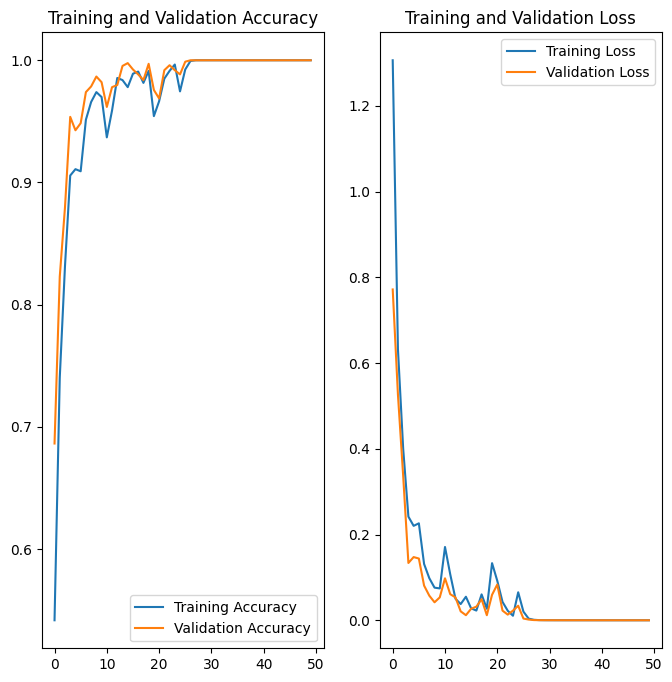

In [91]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Run prediction on a sample image

first image to predict
actual label: Potato___Late_blight
1/1 [==============================] - 0s 412ms/step
predicted label: Potato___Late_blight


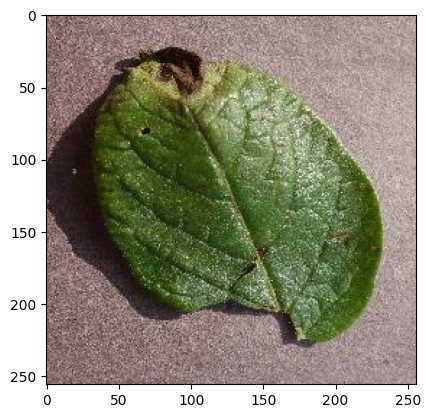

In [92]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

# Write a function for inference

In [93]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

* Now run inference on few sample images

1/1 [==============================] - 0s 29ms/step


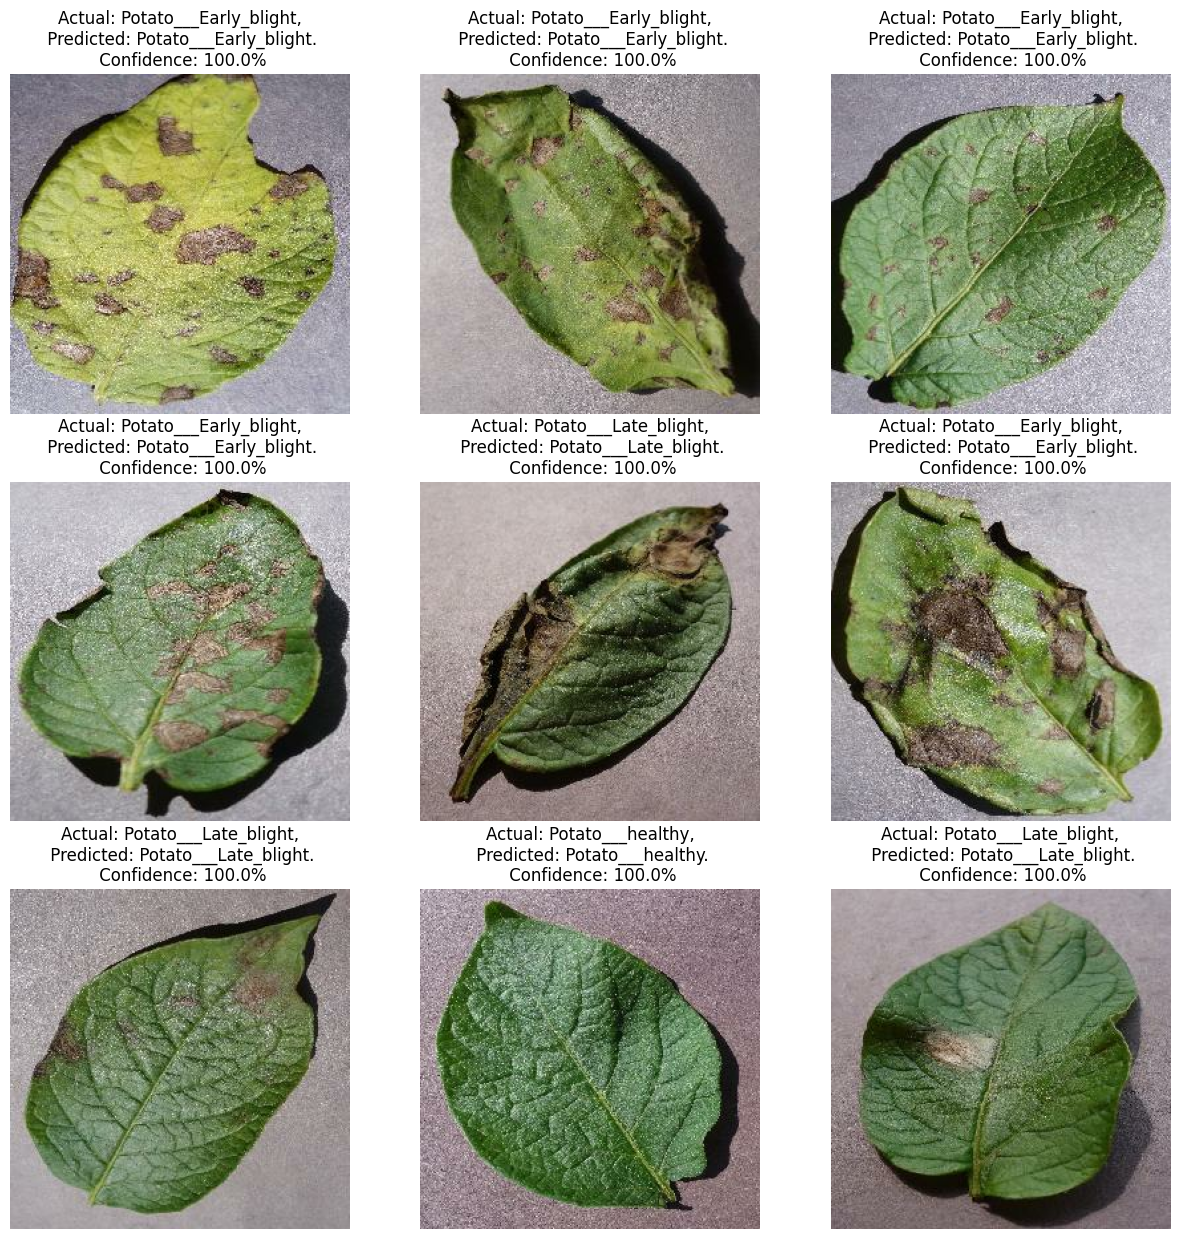

In [94]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [95]:
model.save("../potatoes.h5")

C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
